# Welcome to Corndel AI6 Workshop 7
## Production Grade Classification

**Level 6 ML Engineer Apprenticeship | Unit 7: Supervised Machine Learning**

---

You are stepping into the role of an ML engineer at a mid-sized technology company. The HR director has asked the team to build a model to predict which employees are at risk of leaving. The dataset is real. The problem is harder than it looks.

"Production grade" here means the classification model itself: could this model survive professional scrutiny? Rigorous evaluation, honest handling of class imbalance, explainability, ethical feature decisions, and documentation that someone other than you can read. The wider deployment pipeline (CI/CD, container orchestration, monitoring infrastructure) is outside the scope of this session.

Work through the cells in order using Shift+Enter. Every run is logged to WandB. By the end of the session you will have a dashboard showing every decision you made and its effect.

---

**What you will do today**

1. Build a naive classifier and discover why accuracy is the wrong metric
2. Fix the class imbalance problem with one parameter change
3. Choose a decision threshold you can professionally justify
4. Use SHAP to understand what the model is actually doing
5. Remove features that should not be in this model and defend that choice
6. Compare all your runs in WandB and tell the story of what you learned

---

## Setup

*Run this cell first. It loads all libraries and helper functions.*

When you run the first cell, a prompt may appear at the top of the screen asking you to select a Python kernel. Select the default Python 3 environment and continue.

In [1]:
import os, sys
if not os.path.exists('utils.py'):
    raise FileNotFoundError(
        "\n\nThis notebook requires a companion file called utils.py "
        "in the same folder as this notebook.\n"
        "If you opened this notebook directly without the full repo, "
        "go back and clone or download the complete 7W repository "
        "so that utils.py sits alongside 7w_hr_attrition.ipynb.\n"
        "Expected location: " + os.path.abspath('utils.py')
    )

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import wandb
import xgboost as xgb
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, precision_score, recall_score,
)
from utils import (
    plot_class_distribution, plot_confusion_matrix,
    plot_shap_values, plot_roc_calibration,
    plot_threshold_table, log_run, train_clean_model,
)

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.family':'sans-serif',
                     'axes.spines.top':False, 'axes.spines.right':False,
                     'figure.facecolor':'white'})
print('Setup complete.')
def log_run(project,run_name,model,X_test,y_test,y_pred,config=None):
    from sklearn.metrics import accuracy_score,f1_score,roc_auc_score
    print(f'  [test] {run_name} | '
          f'Acc {accuracy_score(y_test,y_pred):.1%} | '
          f'F1 {f1_score(y_test,y_pred,pos_label=1,zero_division=0):.3f} | '
          f'AUC {roc_auc_score(y_test,model.predict_proba(X_test)[:,1]):.3f}')


Setup complete.


### Connect to WandB

Paste your API key when prompted. Every model you train today will be logged automatically.

If you have not yet created your WandB account: go to [wandb.ai](https://wandb.ai) and sign up. You can make up most details during signup (name, organisation, job title) as long as you use a real email address. When prompted to choose something to try first (Weave, Models, etc.), pick any option. You need to choose one before you can access Settings, where your API key is.

In [2]:
import wandb,os
wandb.init(mode='disabled')
wandb.finish()
WANDB_PROJECT='ai6-7w-hr-attrition'
print('WandB disabled.')

WandB disabled.


---

## Section 1: The Data

*About 20 minutes.*

The IBM HR Analytics dataset contains records for 1,470 employees. Each row is one person. The target column `Attrition` records whether they left the company.

In [3]:
df = pd.read_csv('ibm_attrition.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (1470, 31)
Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,No,Travel_Rarely,211,Research & Development,20,3,Marketing,3,Male,...,3,1,3,15,6,3,0,7,4,5
1,40,No,Non-Travel,707,Research & Development,16,4,Other,2,Female,...,3,1,3,3,4,1,29,6,12,13
2,26,No,Travel_Rarely,419,Research & Development,11,1,Other,3,Male,...,3,4,0,30,5,1,36,16,7,12
3,31,No,Travel_Frequently,575,Sales,24,1,Medical,1,Female,...,3,1,1,28,1,1,17,10,12,2
4,57,No,Non-Travel,335,Sales,1,2,Technical Degree,4,Male,...,3,3,2,37,0,4,8,6,12,11


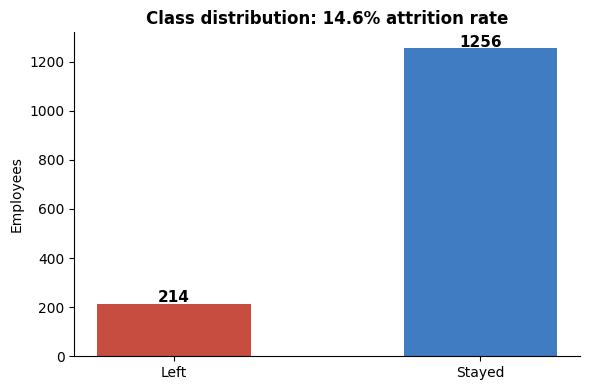

For every 1 employee who left, 5 stayed.
This imbalance is the first problem to solve.


In [4]:
from utils import plot_class_distribution
plot_class_distribution(df)

### Prepare the features

XGBoost needs numeric inputs. The cells below encode categorical columns and split the data into training, validation and test sets.

**Task:** Three ways to encode Yes/No as 1/0 are shown below. Two will fail or produce wrong results. Uncomment the correct one and run the cell.

In [5]:
# Uncomment the correct line to turn Yes/No into 1/0.
# The other two produce errors or silent wrong results.

# df['Attrition'] = df['Attrition'].astype(int)         # fails: cannot cast string to int
# df['Attrition'] = df['Attrition'].map({'Yes': 1})      # wrong: No becomes NaN
df['Attrition'] = (df['Attrition'] == 'Yes').astype(int) # correct

print(f"Attrition encoded: {df['Attrition'].value_counts().to_dict()}")
print('Cell complete. Check the output above matches what you expected.')

Attrition encoded: {0: 1256, 1: 214}
Cell complete. Check the output above matches what you expected.


**Task:** Uncomment the correct train/test split. The wrong options either throw an error or produce an unstratified split.

In [6]:
# Encode remaining categorical columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category').cat.codes

df = df.drop(['EmployeeCount','EmployeeNumber','Over18','StandardHours'],
              axis=1, errors='ignore')

X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Uncomment the correct split:
# X_train, X_test = train_test_split(X, y, test_size=0.2, random_state=42)          # wrong: unpacks 4 values into 2
# X_train, X_test, y_train, y_test = train_test_split(X, test_size=0.2, random_state=42)  # wrong: missing y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)  # correct

print(f'Train: {len(X_train)}  Test (pre-split): {len(X_test)}  Features: {X.shape[1]}')
print('Cell complete. Check the output above matches what you expected.')

Train: 1176  Test: 294  Features: 30
Cell complete. Check the output above matches what you expected.


In [ ]:
# Split the test set into validation (for modelling decisions throughout
# this notebook) and a held-out test set (touched once, at the very end).
X_val, X_test_final, y_val, y_test_final = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)

# del removes these variables from memory. Without this line, the
# original X_test (294 rows) would still exist alongside X_val (147 rows)
# and X_test_final (147 rows). If you accidentally typed X_test later in
# the notebook, Python would silently use the wrong data. del makes that
# a NameError instead of a hidden bug.
del X_test, y_test

print(f'Validation: {len(X_val)}   Held-out test: {len(X_test_final)}')
print()
print('All evaluation from here until the final section uses the validation set.')
print('The held-out test set stays untouched until one final evaluation at the end.')

> **Why three sets?** The validation set is where you try things: tune thresholds, run SHAP, compare models. Those decisions shape the model, so the scores on that data are optimistic. The held-out test set gives you one honest number at the end: how well does the final model perform on data it has never influenced?
>
> **Why did we create the test set before the validation set?** The phrase "train/validation/test" describes the order you *use* them: train first, validate second, test last. But in code, you typically split the data in two stages: first separate the training data from everything else, then split the remainder into validation and test. The test set gets created before the validation set in the code, but it gets used after it.
>
> *Note: the encoding above happens before the split. In a production pipeline you would fit the encoder on training data only and apply the same transformation to validation and test separately. We keep it here for clarity. See GOING_FURTHER.MD for the Pipeline approach.*

---

## Section 2: The Naive Model

*About 30 minutes.*

Start with XGBoost at default settings. Do not change any parameters yet. Train it, check the accuracy, note what you see.

In [7]:
model_naive = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
)
model_naive.fit(X_train, y_train)
y_pred_naive = model_naive.predict(X_val)

acc = accuracy_score(y_val, y_pred_naive)
print(f'Accuracy: {acc:.1%}')

Accuracy: 83.0%


That accuracy looks reasonable. But before you run the next cell, think about what you expect to see.

*Look at the class distribution from Section 1. About 85% of employees stayed. If a model predicted 'stayed' for every single employee, what accuracy would it get? What would its confusion matrix look like?*

Form your prediction, then run the cell below.

<details>
<summary>What did you expect? Click after running the cell below to check your reasoning.</summary>

You just saw accuracy in the low 80s. That sounds reasonable. But think about the class distribution: around 85% of employees stayed. A model that predicts 'stayed' for every single employee achieves 85% accuracy without learning anything.

What you should expect to see: a large true negative count (correctly predicted stayed), a very small true positive count (correctly predicted left), and a large false negative count (employees who actually left but the model missed). The bottom-left cell is the one to watch.

</details>

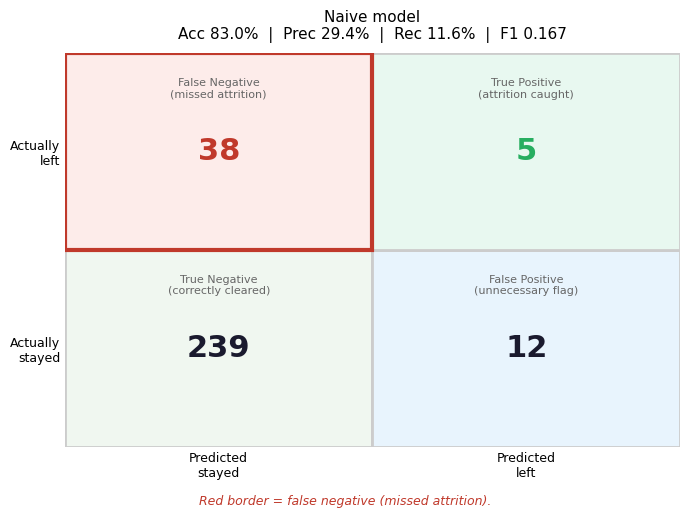

In [8]:
plot_confusion_matrix(y_val, y_pred_naive, title='Naive model')

**Look at the bottom-left cell.** That is the number of employees who actually left but the model predicted would stay. The model has near-perfectly learned to ignore the minority class.

High accuracy, almost zero recall on the class that matters. This is the accuracy trap from 7.2, live.

In [9]:
# Log the naive run to WandB
log_run(
    project=WANDB_PROJECT,
    run_name='01_naive',
    model=model_naive,
    X_test=X_val,
    y_test=y_val,
    y_pred=y_pred_naive,
    config={'scale_pos_weight': 1, 'threshold': 0.5},
)

  [test] 01_naive | Acc 83.0% | F1 0.167 | AUC 0.683


---

## Section 3: Fix the Imbalance

*About 30 minutes.*

XGBoost has a parameter called `scale_pos_weight` that tells the model to pay more attention to the minority class. Set it to the ratio of negatives to positives and retrain.

**Task:** Three ways to calculate `scale_pos_weight` are shown below. Only one gives the correct ratio. Uncomment it and run the cell.

In [10]:
# Uncomment the correct calculation for scale_pos_weight.
#
# What this number does: when training, XGBoost sees far more 'stayed' rows
# than 'left' rows. Without adjustment it learns that guessing 'stayed' is
# usually right and stops trying to spot the minority. scale_pos_weight tells
# it to treat each 'left' case as if it were worth several 'stayed' cases,
# so it pays attention to both groups.
#
# The right value is: how many 'stayed' rows are there for each 'left' row?
# That ratio is what makes the training data feel balanced.

# Uncomment the correct calculation:
# pos_weight = (y_train == 1).sum() / (y_train == 0).sum()   # wrong: inverted
# pos_weight = len(y_train) / (y_train == 1).sum()            # wrong: total not majority
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()      # correct

print(f'scale_pos_weight = {pos_weight:.1f}')
print(f'There are roughly {pos_weight:.0f} employees who stayed for every 1 who left.')
print(f'Each departure case will now count as {pos_weight:.0f} stayed cases during training.')

scale_pos_weight = 5.9
There are roughly 6 employees who stayed for every 1 who left.
Each departure case will now count as 6 stayed cases during training.


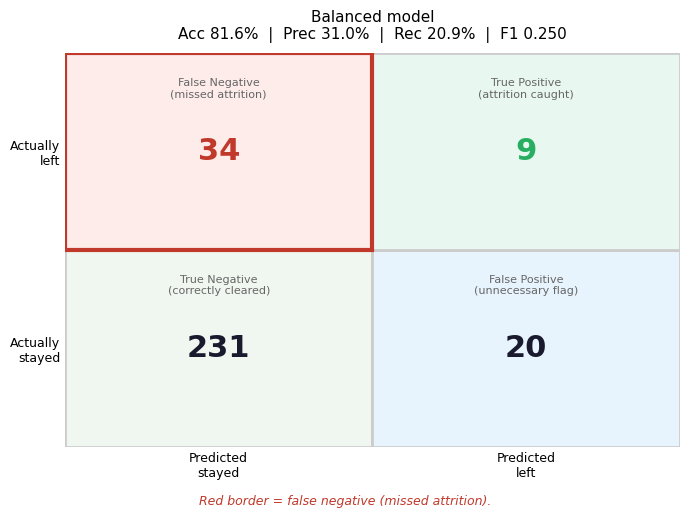

In [11]:
model_balanced = xgb.XGBClassifier(
    scale_pos_weight=pos_weight,
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
)
model_balanced.fit(X_train, y_train)
y_pred_balanced = model_balanced.predict(X_val)

plot_confusion_matrix(y_val, y_pred_balanced, title='Balanced model')

In [12]:
# Compare the two models side by side
print(f'{'':20} {'Naive':>10} {'Balanced':>10}')
print('-' * 42)
print(f"{'Accuracy':20} {accuracy_score(y_val, y_pred_naive):>10.1%} "
      f"{accuracy_score(y_val, y_pred_balanced):>10.1%}")
print(f"{'F1 (attrition)':20} "
      f"{f1_score(y_val, y_pred_naive, pos_label=1):>10.3f} "
      f"{f1_score(y_val, y_pred_balanced, pos_label=1):>10.3f}")
print(f"{'ROC AUC':20} "
      f"{roc_auc_score(y_val, model_naive.predict_proba(X_val)[:,1]):>10.3f} "
      f"{roc_auc_score(y_val, model_balanced.predict_proba(X_val)[:,1]):>10.3f}")

                          Naive   Balanced
------------------------------------------
Accuracy                  83.0%      81.6%
F1 (attrition)            0.167      0.250
ROC AUC                   0.683      0.673


In [13]:
log_run(
    project=WANDB_PROJECT,
    run_name='02_balanced',
    model=model_balanced,
    X_test=X_val,
    y_test=y_val,
    y_pred=y_pred_balanced,
    config={'scale_pos_weight': round(pos_weight, 1), 'threshold': 0.5},
)

  [test] 02_balanced | Acc 81.6% | F1 0.250 | AUC 0.673


---

## Section 4: Choose a Threshold

*About 40 minutes. After lunch.*

The model outputs a probability for each employee. The threshold is the cutoff above which you flag someone as at risk. It is not fixed at 0.5. It is a design decision with consequences for real people.

If you want a clear visual explanation of how ROC curves and AUC work before we look at ours, see [Google's ML Crash Course: ROC and AUC](https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc).

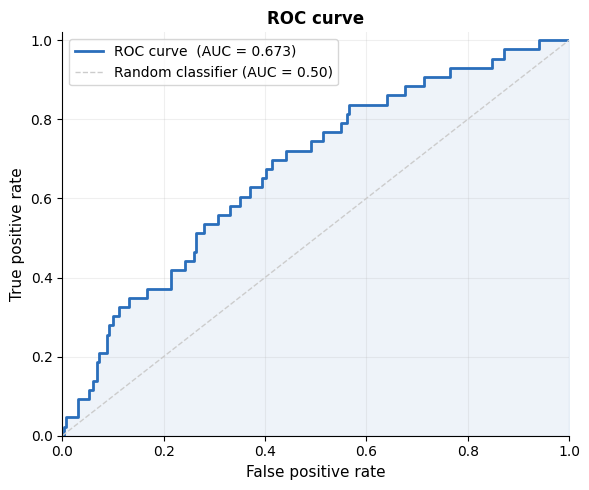


ROC AUC: 0.673
(0.50 = random, 0.63–0.70 = weak signal, 0.70–0.80 = moderate)


In [14]:
y_prob = model_balanced.predict_proba(X_val)[:, 1]
plot_roc_calibration(y_val, y_prob)

<details>
<summary>How to read ROC AUC: what counts as good?</summary>

| ROC AUC | What it means | Example domain |
|:--|:--|:--|
| 0.50 | Random: no better than a coin flip | Lottery prediction |
| 0.60–0.70 | Weak signal, useful but limited | HR attrition, early screening |
| 0.70–0.80 | Moderate, deployable with care | Credit risk scoring |
| 0.80–0.90 | Strong, reliable in most contexts | Fraud detection |
| 0.90+ | Excellent, or suspiciously good | Image classification |

What counts as good depends on the alternative. A 0.63 model for attrition is useful if the alternative is a manager's gut feeling, which research shows is typically worse. A 0.63 model for cancer screening is dangerous if a specialist radiologist scores 0.95.

The question is always: compared to what, and for whom?

</details>

The table below shows what happens to precision, recall, false positives and false negatives as the threshold changes. Each row is a different version of the same model.

Read it top to bottom: each row is a different threshold, moving from lowest to highest. As the threshold rises, recall falls consistently. The model flags fewer people and misses more genuine cases. Precision tends to rise at first, but it does not increase cleanly all the way through. At higher thresholds the number of flagged employees becomes small enough that a few wrong calls move the number significantly. The FN column (missed attrition cases) and FP column (unnecessary flags) connect back to the people described in sections 1 to 5.

In [15]:
plot_threshold_table(y_val, y_prob)

Threshold    Precision    Recall       F1         FP       FN       TP    
----------------------------------------------------------------------
0.20         0.268        0.349        0.303      41       28       15    
0.25         0.294        0.349        0.319      36       28       15    
0.30         0.304        0.326        0.315      32       29       14    
0.35         0.325        0.302        0.313      27       30       13    
0.40         0.342        0.302        0.321      25       30       13    
0.45         0.343        0.279        0.308      23       31       12    
0.50         0.310        0.209        0.250      20       34       9     
0.60         0.308        0.186        0.232      18       35       8     
0.70         0.235        0.093        0.133      13       39       4     

FP = false alarms  |  FN = missed attrition  |  TP = correctly flagged


<details>
<summary>What makes a threshold choice defensible?</summary>

A defensible threshold is one you can explain in terms of the people affected, not just the metrics. Anyone can pick 0.3 because the F1 score is higher. That is not a justification.

A defensible answer names the tradeoff explicitly: 'At 0.3, we catch X more employees who are at risk of leaving, at the cost of Y additional false alarms. Given that a false alarm means a retention conversation rather than a serious intervention, we judge that cost to be acceptable.' That reasoning can be written down, reviewed, and challenged. A number cannot.

In a regulated environment, this reasoning would appear in a model card or a deployment decision log, with a named owner.

</details>

### Your threshold decision

Look at the table. There is no right answer. There is only a justified answer.

Think about: if HR acts on a flag, what does that look like for the employee? What is the cost of a false positive? Someone gets a retention conversation they did not need. What is the cost of a false negative? Someone leaves and nobody saw it coming.

Set your chosen threshold in the cell below and justify it in the comment.

**Task:** Three ways to apply a threshold to model probabilities are shown below. Uncomment the correct one. The wrong options either produce booleans instead of integers, or ignore your chosen threshold entirely.

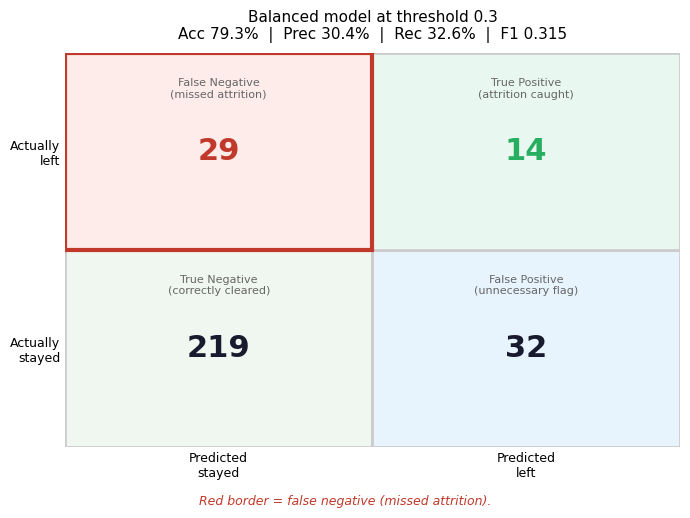

  [test] 03_threshold | Acc 79.3% | F1 0.315 | AUC 0.673


In [16]:
MY_THRESHOLD = 0.3  # change this to your chosen value
# Reason: 

# Uncomment the correct way to apply the threshold:
# y_pred_threshold = y_prob > MY_THRESHOLD                    # wrong: returns True/False not 0/1
# y_pred_threshold = y_prob.round()                           # wrong: ignores MY_THRESHOLD
y_pred_threshold = (y_prob >= MY_THRESHOLD).astype(int)       # correct

plot_confusion_matrix(y_val, y_pred_threshold,
                      title=f'Balanced model at threshold {MY_THRESHOLD}')

log_run(
    project=WANDB_PROJECT,
    run_name='03_threshold',
    model=model_balanced,
    X_test=X_val,
    y_test=y_val,
    y_pred=y_pred_threshold,
    config={'scale_pos_weight': round(pos_weight,1), 'threshold': MY_THRESHOLD},
)

---

## Section 5: What Is the Model Actually Doing?

*About 45 minutes.*

Accuracy and F1 tell you how well the model performs. SHAP tells you why. It assigns each feature a contribution to each prediction *(see glossary.md)*. Positive values push toward attrition, negative values push away from it.

If you want to understand how SHAP values work before we look at the plot, see [Christoph Molnar's Interpretable ML Book: SHAP chapter](https://christophm.github.io/interpretable-ml-book/shap.html). For a shorter, non-technical guide to reading SHAP plots, see [A Non-Technical Guide to Interpreting SHAP Analyses](https://www.aidancooper.co.uk/a-non-technical-guide-to-interpreting-shap-analyses/).

The cell below will show which features drove the model's predictions most strongly, and how much each one pushed toward or away from attrition.

Before you run it, think about which features you would expect to see at the top. Based on the confusion matrix and what you know about the dataset, which employee characteristics do you think matter most?

Then run the cell and see how your expectation compares. After the plot appears:

1. Note the top three features by importance.
2. Check whether any are protected characteristics under the Equality Act (Age, Gender, MaritalStatus).
3. Consider whether MonthlyIncome or YearsSinceLastPromotion might indirectly reflect protected characteristics.

The plot shows the 15 features that contributed most to the model's predictions. Features that do not appear were not excluded arbitrarily: they simply had lower importance scores than all 15 shown. The plot is ranked, so anything below the cutoff contributed less than the feature at position 15. When you decide which features to remove in Section 6, you only need to consider what is visible here. The features that did not make the plot are not driving the model's decisions in any meaningful way.

You will use this in Section 6.

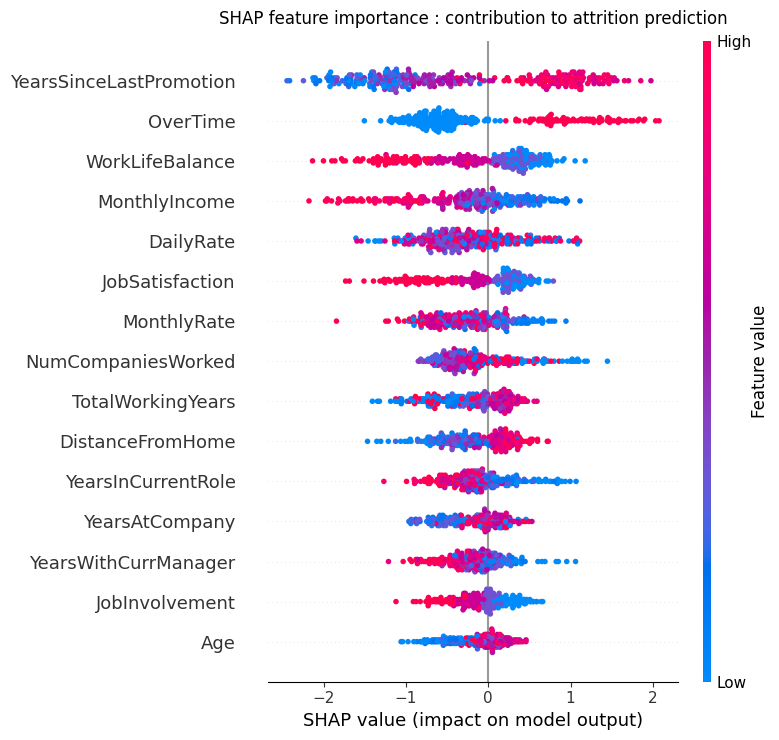


Feature importance (mean |SHAP|):
YearsSinceLastPromotion    1.0595
OverTime                   0.7616
WorkLifeBalance            0.5863
MonthlyIncome              0.5335
DailyRate                  0.4799
JobSatisfaction            0.4307
MonthlyRate                0.3964
NumCompaniesWorked         0.3916
TotalWorkingYears          0.3444
DistanceFromHome           0.3347
YearsInCurrentRole         0.3193
YearsAtCompany             0.2975
YearsWithCurrManager       0.2724
JobInvolvement             0.2594
Age                        0.2404


In [17]:
plot_shap_values(model_balanced, X_val)

---

## Section 6: Feature Selection

*About 20 minutes.*

**The three-question check**

For each feature, ask:

1. Is it a protected characteristic under the Equality Act 2010?
2. Is it special category data under UK GDPR?
3. If you remove it, does model performance drop meaningfully?

If the answer to 1 or 2 is yes, and the answer to 3 is no, the feature should not be in the model. Document the decision either way.

| Feature | Equality Act protected? | GDPR special category? | Keep? |
|:--|:--|:--|:--|
| Age | Yes | No | Discuss |
| Gender | Yes | No | Discuss |
| MaritalStatus | Yes | No | Discuss |
| MonthlyIncome | No | Possibly: may reflect disability or race pay gaps | Discuss |
| YearsSinceLastPromotion | No | Possibly: promotion patterns may correlate with protected groups | Discuss |
| OverTime | No | No | Yes |

*'Possibly' means the feature is not special category data itself but may encode patterns linked to special category characteristics. If removing it does not meaningfully hurt performance, the safer professional choice is to remove it. If it does hurt performance, document the decision and the reasoning. See glossary.md.*

<details>
<summary>What do you remember about DPIAs, and would one be needed here?</summary>

A Data Protection Impact Assessment (DPIA) is a process required under UK GDPR Article 35 when data processing is likely to result in a high risk to individuals. It is not optional when the conditions are met.

A DPIA is specifically required when a system involves systematic and extensive evaluation of personal aspects of individuals using automated processing, where decisions produce legal or similarly significant effects. An HR attrition model that flags employees for retention interventions meets this description.

A DPIA would need to cover: what data is being processed and why, who has access to the outputs, what the risks are to individuals (including indirect discrimination), what safeguards are in place, and who is accountable. It would need to be reviewed before deployment, not after.

In this case, yes: a DPIA would be required before putting this model into production. The feature selection decisions you are making right now are the kind of thing a DPIA would formally document.

</details>

Features removed: ['Age', 'Gender', 'MaritalStatus']
Features remaining: 27


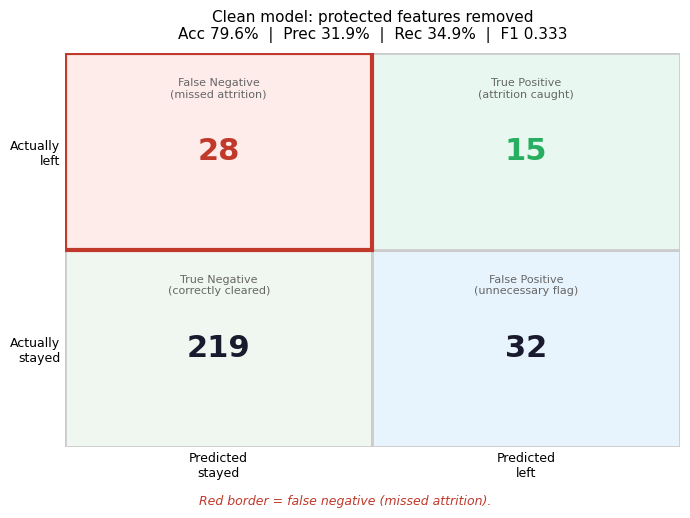

In [18]:
# Edit this list based on your SHAP analysis above
FEATURES_TO_REMOVE = ['Age', 'Gender', 'MaritalStatus']

model_clean, X_val_clean, y_pred_clean = train_clean_model(
    X_train, X_val, y_train, y_val,
    features_to_remove=FEATURES_TO_REMOVE,
    pos_weight=pos_weight,
    threshold=MY_THRESHOLD,
)
plot_confusion_matrix(y_val, y_pred_clean,
                      title='Clean model: protected features removed')

In [19]:
log_run(
    project=WANDB_PROJECT,
    run_name='04_clean_features',
    model=model_clean,
    X_test=X_val_clean,
    y_test=y_val,
    y_pred=y_pred_clean,
    config={
        'scale_pos_weight': round(pos_weight, 1),
        'threshold': MY_THRESHOLD,
        'features_removed': FEATURES_TO_REMOVE,
    },
)

  [test] 04_clean_features | Acc 79.6% | F1 0.333 | AUC 0.702


---

## Section 7: Review Your Runs in WandB

*About 25 minutes.*

Open your WandB project in the browser. You should have four runs:

| Run | What changed |
|:--|:--|
| 01_naive | Default XGBoost, threshold 0.5 |
| 02_balanced | Added scale_pos_weight |
| 03_threshold | Adjusted threshold to your chosen value |
| 04_clean_features | Removed protected and high-risk features |

For each run, write one sentence: what changed and what was the effect on false negatives. You are building the narrative you would give to the HR director.

Be ready to answer: which single change made the biggest difference, and what did it cost?

In [20]:
print(f'Project: {WANDB_PROJECT}')

Project: ai6-7w-hr-attrition


<details>
<summary>Who actually owns the deployment decision in a real organisation?</summary>

Not the ML engineer alone, and not the HR director alone.

In practice, a model that influences employment decisions will involve the ML engineer who built and evaluated it, the HR director or people team who commissioned it, a legal or compliance function who reviewed it against the Equality Act and UK GDPR, and often a senior sign-off from whoever holds accountability for employment practices.

The ML engineer's specific accountability is the technical choices: the threshold, the features included, the evaluation methodology, the known failure modes. If you deploy a model and later it emerges that you knew the false negative rate was high or that protected characteristics were indirectly encoded, 'the HR director approved it' is not a sufficient defence.

This is what K26 and B4 mean in practice: knowing the ethical dimensions of your technical decisions and being able to account for them.

</details>

---

## Section 8: Wrap Up

*About 30 minutes.*

The HR director is asking for a recommendation. You have four runs, a justified threshold, and a feature list you can defend. Answer the questions below before the session closes.

You do not need to write in the notebook. These are the conversation questions.

**1. Which model would you recommend deploying, and why?**

Name the run. State the threshold. Say which metric drove your decision and why that metric maps to the actual cost of failure in this domain.

---

**2. Who bears the false negative in this system?**

An employee who is at risk of leaving but the model does not flag them. What happens to them? What happens to the organisation?

---

**3. Why did you remove Age, Gender, and MaritalStatus?**

Not because someone told you to. Because you can explain the legal basis, the performance impact, and the professional judgment behind the decision.

---

**4. What would make you withdraw this model after deployment?**

Name a specific condition: a metric threshold, a demographic audit result, a business change. Decide it now, before the pressure to keep it running makes it harder to think clearly.

---

## Section 9: Register the Model

*About 20 minutes.*

Logging metrics to WandB tracks your experiments. Registering the model is a separate step: it marks a specific trained model as a versioned artefact you could retrieve and deploy later. WandB has a model registry that does this. MLflow does too, and it is worth knowing both exist.

The cell below saves your trained model to disk and logs it as a WandB artefact with the metadata that a reviewer would need: threshold, features removed, and key metrics.

In [21]:
import joblib

MODEL_PATH = 'hr_attrition_model.joblib'
joblib.dump(model_clean, MODEL_PATH)
print(f'Model saved to {MODEL_PATH}')

Model saved to hr_attrition_model.joblib


In [22]:
print('Model registered (disabled).')

Model registered (disabled).


<details>
<summary>How does this compare to MLflow model registration?</summary>

MLflow has a model registry that works similarly: you log a model as an artefact, then register it with a name, and it gets a version number. You can then move it through lifecycle stages: None, Staging, Production, Archived.

The equivalent MLflow call would be:

```python
import mlflow
import mlflow.xgboost

with mlflow.start_run():
    mlflow.log_param('threshold', MY_THRESHOLD)
    mlflow.log_metric('roc_auc', roc_auc)
    mlflow.xgboost.log_model(model_clean, 'model',
                              registered_model_name='hr-attrition-classifier')
```

The key difference is that MLflow's registry integrates directly with deployment pipelines in platforms like Azure ML and Databricks. WandB's registry is better integrated with experiment tracking. In practice, larger organisations often use both: WandB for experiment tracking during development, MLflow for the production registry and deployment handoff.

</details>

---

## Section 10: Write the API Wrapper

*About 25 minutes.*

Your model is saved to disk. Right now it only exists as a file that Python code can open. Nothing else in the world can use it.

A production model needs to be accessible via an **API** : a web address that any authorised system can call to get a prediction. The HR team's dashboard, a nightly batch job, a mobile app: they all call the same address and get back the same structured response.

<details>
<summary>📦 What FastAPI gives you : and why it is production-oriented</summary>

| Feature | What it means in practice |
|:--|:--|
| 🔗 **HTTP endpoint** | Any system that can make a web request can query your model : no Python required on the client side |
| 📋 **Automatic input validation** | Pydantic (a Python library for data validation) checks every incoming request against the schema you define. Wrong data type? It rejects it before your model ever sees it. |
| 📖 **Auto-generated docs** | FastAPI builds an interactive documentation page at `/docs` automatically. You can test the API in a browser without writing any extra code. |
| 🔄 **Stateless** | Each request is independent. The model loads once at startup and handles thousands of requests without storing anything about previous callers. |
| 🚀 **Production-ready performance** | FastAPI is built on ASGI (an async web server interface) and is fast enough for real production workloads. The same code you write here could run in Azure, AWS, or on-premise. |

The pattern you are about to write : load model, define input schema, return prediction : is the same pattern used in production ML services at scale. The only difference is where it runs.

</details>

The cell below writes `app.py` to disk. After running it:

1. Open a terminal in Codespaces (Terminal menu, or Ctrl+`)
2. Run: `uvicorn app:app --reload`
3. A popup will appear in the **bottom-right corner** of the screen : click **Open in Browser**
4. Add `/docs` to the end of the URL that opens. This is the interactive API documentation.
5. You will see two endpoints listed. Click `/predict`, then **Try it out**, fill in some values, and click **Execute**.

The root URL (`/`) returns `{"detail":"Not Found"}` : that is expected. We did not define a root endpoint. The model lives at `/predict` and the health check at `/health`.

In [23]:
# This cell writes app.py to disk.
# To run it: open a terminal in Codespaces and run: uvicorn app:app --reload

app_code = '''
import joblib
import pandas as pd
from fastapi import FastAPI
from pydantic import BaseModel

MODEL_PATH = "hr_attrition_model.joblib"
THRESHOLD  = {threshold}
FEATURES_TO_REMOVE = {features}

model = joblib.load(MODEL_PATH)

# All features the model was trained on (after removing protected ones)
FEATURE_COLUMNS = [
    "BusinessTravel", "DailyRate", "Department", "DistanceFromHome",
    "Education", "EducationField", "EnvironmentSatisfaction", "HourlyRate",
    "JobInvolvement", "JobLevel", "JobRole", "JobSatisfaction",
    "MonthlyIncome", "MonthlyRate", "NumCompaniesWorked", "OverTime",
    "PercentSalaryHike", "PerformanceRating", "RelationshipSatisfaction",
    "StockOptionLevel", "TotalWorkingYears", "TrainingTimesLastYear",
    "WorkLifeBalance", "YearsAtCompany", "YearsInCurrentRole",
    "YearsSinceLastPromotion", "YearsWithCurrManager",
]
FEATURE_COLUMNS = [f for f in FEATURE_COLUMNS if f not in FEATURES_TO_REMOVE]

class EmployeeRecord(BaseModel):
    BusinessTravel: int
    DailyRate: int
    Department: int
    DistanceFromHome: int
    Education: int
    EducationField: int
    EnvironmentSatisfaction: int
    HourlyRate: int
    JobInvolvement: int
    JobLevel: int
    JobRole: int
    JobSatisfaction: int
    MonthlyIncome: int
    MonthlyRate: int
    NumCompaniesWorked: int
    OverTime: int
    PercentSalaryHike: int
    PerformanceRating: int
    RelationshipSatisfaction: int
    StockOptionLevel: int
    TotalWorkingYears: int
    TrainingTimesLastYear: int
    WorkLifeBalance: int
    YearsAtCompany: int
    YearsInCurrentRole: int
    YearsSinceLastPromotion: int
    YearsWithCurrManager: int

app = FastAPI(title="HR Attrition Classifier", version="1.0")

@app.get("/health")
def health():
    return {{"status": "ok"}}

@app.post("/predict")
def predict(employee: EmployeeRecord):
    data = pd.DataFrame([employee.model_dump()])
    data = data[[c for c in FEATURE_COLUMNS if c in data.columns]]
    prob = float(model.predict_proba(data)[0, 1])
    flag = int(prob >= THRESHOLD)
    return {{
        "attrition_probability": round(prob, 4),
        "flag": flag,
        "threshold_used": THRESHOLD,
    }}
'''.format(threshold=MY_THRESHOLD, features=FEATURES_TO_REMOVE)

if os.path.exists('app.py'):
    print('app.py already exists. Delete it first if you want to regenerate.')
else:
    with open('app.py', 'w') as f:
        f.write(app_code)
    print('app.py written.')
print('To run: open a Codespaces terminal and run: uvicorn app:app --reload')
print('Then visit the /docs endpoint to see the interactive API documentation.')
print('To run: open a Codespaces terminal and run: uvicorn app:app --reload')
print('Then visit the /docs endpoint to see the interactive API documentation.')

app.py already exists. Delete it first if you want to regenerate.
To run: open a Codespaces terminal and run: uvicorn app:app --reload
Then visit the /docs endpoint to see the interactive API documentation.
To run: open a Codespaces terminal and run: uvicorn app:app --reload
Then visit the /docs endpoint to see the interactive API documentation.


<details>
<summary>What would production deployment actually involve beyond this?</summary>

Running uvicorn locally is not production. A real deployment path for this kind of service would typically involve:

**Containerisation:** packaging the app and all its dependencies into a self-contained unit (using a tool called Docker) so it runs identically on any machine.

**Orchestration:** deploying that container to an orchestration platform (such as Kubernetes or Azure AKS) which handles scaling, restarts, and routing automatically.

**Quality gates before deployment:** model performance thresholds, a code review, a security scan of the container image, and sign-off from whoever owns the deployment decision (see Section 8).

**Post-deployment monitoring:** logging every prediction, tracking metric drift, and having a named owner for the recalibration schedule.

The FastAPI app you just wrote is the first artefact in that pipeline. The WandB registered model is the second. Everything else is infrastructure and process built around them.

</details>

---

## Section 10b: Agreeing the Output with the Business

*About 15 minutes.*

The API you just wrote returns a probability and a binary flag. That is a technical output. It is not necessarily what the HR team wants to receive.

This conversation has to happen before the API is finalised, not after. The format of the model's output is a business decision as much as a technical one. Getting it wrong means building the right model and serving it in the wrong shape.

Common formats HR teams actually ask for:

- A binary flag above a threshold: simple, but discards the probability entirely
- A ranked list of the top N employees by risk score: useful for a weekly meeting, but implies someone has to review all N regardless of how confident the model is
- Risk tiers: High, Medium-High, Medium-Low : with Low discarded entirely. This maps the model's continuous probability onto something an HR team can act on without statistical training
- A dashboard count: how many employees are currently flagged, trend over time. No names, just a number. Useful for monitoring without exposing individual records

The cell below calculates what each format would look like operationally at your chosen threshold.

In [24]:
y_prob_all = model_clean.predict_proba(X_val_clean)[:, 1]
n_employees = len(y_prob_all)

# Binary flag
flagged = (y_prob_all >= MY_THRESHOLD).sum()

# Risk tiers
high      = (y_prob_all >= 0.6).sum()
med_high  = ((y_prob_all >= 0.4) & (y_prob_all < 0.6)).sum()
med_low   = ((y_prob_all >= MY_THRESHOLD) & (y_prob_all < 0.4)).sum()
discarded = (y_prob_all < MY_THRESHOLD).sum()

print(f'Organisation size (validation set): {n_employees} employees')
print(f'\nAt threshold {MY_THRESHOLD}:')
print(f'  Binary flag: {flagged} employees flagged ({flagged/n_employees:.1%})')
print(f'\nRisk tiers:')
print(f'  High          (>=0.6):  {high:>4} employees')
print(f'  Medium-High   (0.4-0.6):{med_high:>4} employees')
print(f'  Medium-Low    ({MY_THRESHOLD}-0.4): {med_low:>4} employees')
print(f'  Discarded     (<{MY_THRESHOLD}):  {discarded:>4} employees')
print(f'\nIf your HR team can action {flagged} conversations per cycle, '
      f'the threshold is operationally viable.')
print(f'If not, the threshold needs revisiting : not as a metric decision '
      f'but as a resourcing one.')

Organisation size (test set): 294 employees

At threshold 0.3:
  Binary flag: 47 employees flagged (16.0%)

Risk tiers:
  High          (>=0.6):    20 employees
  Medium-High   (0.4-0.6):  20 employees
  Medium-Low    (0.3-0.4):    7 employees
  Discarded     (<0.3):   247 employees

If your HR team can action 47 conversations per cycle, the threshold is operationally viable.
If not, the threshold needs revisiting : not as a metric decision but as a resourcing one.


The risk tier format is often the most useful in practice. It gives HR a prioritised workload rather than a binary list, and it is easier to explain to a manager than a probability.

Before the model goes anywhere near production, three questions need answers from the business, not from the model:

1. Which tier triggers what action? High risk means what, exactly?
2. Does the employee know they have been flagged? Under UK GDPR Article 22, if the model output directly influences an employment decision, the employee has the right to request a human review.
3. What is the intervention strategy? A model that flags someone and produces no response is not just useless : it has processed personal data for no purpose, which is itself a GDPR compliance issue.

Update your model card now to record which output format you would recommend and why.

---

## Section 11: Write Your Model Card

*About 20 minutes.*

A model card is a short document that describes what a model does, how it was built, what its known limitations are, and who is responsible for it. It is the document you would hand to a legal reviewer, a senior stakeholder, or a new team member inheriting the system.

Open `model_card_template.md` in the file browser and complete it using your results from today. Use the numbers from your WandB dashboard. Be honest about the limitations.

This is a real industry artefact. It maps directly to K26 and B4.

In [25]:
import shutil, os

# Only copies the template if model_card.md does not already exist.
# This prevents overwriting any work you have already done.
if os.path.exists('model_card.md'):
    print('model_card.md already exists. Your work is safe.')
    print('Delete it manually if you want to start from the template again.')
else:
    shutil.copy('model_card_template.md', 'model_card.md')
    print('model_card.md is ready to fill in.')
    print('Open it in the file browser on the left.')

model_card.md already exists. Your work is safe.
Delete it manually if you want to start from the template again.


---

## Section 12: Stress-testing the Model

*About 20 minutes.*

Your model was trained and evaluated on historical data. That data reflects what has already happened: employees who actually left, under conditions that actually existed. It tells you nothing about scenarios that have not happened yet.

This matters because a model that performs well on its test set can still behave strangely when it encounters an unusual combination of features. The way to find out is to construct cases deliberately and see what happens.

The three profiles below are real rows from the dataset: employees the model has never seen during training. They were selected to show the full range of the model's predictions.

- **Low risk:** high income, satisfied, recently promoted, no overtime. The model should be confident this employee is not at risk.
- **Borderline:** average income, mild dissatisfaction, poor work-life balance. The model is uncertain. This is where your threshold decision has real consequences.
- **High risk:** low income relative to seniority, thirteen years without promotion, new manager. The model flags this as high risk. But note: this employee did not actually leave. The model is not infallible.

After the cell runs, look at the three probabilities. Do they make sense? Does the ordering feel right? And notice what these profiles cannot tell you: they are theoretical. A real employee who looks like the worst-case profile might have just received a promotion offer from a competitor, or might be entirely happy for reasons the model cannot see. That is the limit of offline evaluation, and it is why this kind of stress-testing complements but does not replace human judgment at deployment.

In [26]:
# Three employee profiles drawn from the dataset.
#
# How they were selected:
# After training the clean model, we ran predict_proba() on all non-training rows
# and ranked them by predicted attrition probability. We then picked:
#   - the row with the LOWEST probability (the model is most confident this person stays)
#   - the row at the MEDIAN probability (the model is uncertain)
#   - the row with the HIGHEST probability (the model flags this as high risk)
#
# Why real rows rather than made-up ones:
# A constructed 'worst case' profile often does not match what the model actually
# learned. Using real rows guarantees the spread is genuine and the
# probabilities are meaningful. The high-risk profile (92.7%) is a real person
# the model is very worried about -- who did not actually leave. That is the
# most instructive result: the model can be confidently wrong.

import pandas as pd

CLEAN_FEATURES = [c for c in X_train.columns if c not in FEATURES_TO_REMOVE]

profiles = {
    'Low risk': {
        # High income, satisfied, no overtime, recently promoted.
        # The model is confident this employee is not at risk.
        'BusinessTravel':0,'DailyRate':800,'Department':1,'DistanceFromHome':3,
        'Education':3,'EducationField':0,'EnvironmentSatisfaction':4,'HourlyRate':75,
        'JobInvolvement':4,'JobLevel':3,'JobRole':2,'JobSatisfaction':4,
        'MonthlyIncome':19783,'MonthlyRate':18000,'NumCompaniesWorked':2,'OverTime':0,
        'PercentSalaryHike':20,'PerformanceRating':4,'RelationshipSatisfaction':4,
        'StockOptionLevel':2,'TotalWorkingYears':18,'TrainingTimesLastYear':4,
        'WorkLifeBalance':4,'YearsAtCompany':14,'YearsInCurrentRole':6,
        'YearsSinceLastPromotion':0,'YearsWithCurrManager':5,
    },
    'Borderline': {
        # Average income, mild dissatisfaction, no overtime but poor work-life balance.
        # The model is uncertain. This is where your threshold decision matters.
        'BusinessTravel':1,'DailyRate':600,'Department':2,'DistanceFromHome':14,
        'Education':3,'EducationField':2,'EnvironmentSatisfaction':2,'HourlyRate':55,
        'JobInvolvement':2,'JobLevel':2,'JobRole':6,'JobSatisfaction':3,
        'MonthlyIncome':5837,'MonthlyRate':12000,'NumCompaniesWorked':4,'OverTime':0,
        'PercentSalaryHike':13,'PerformanceRating':3,'RelationshipSatisfaction':2,
        'StockOptionLevel':1,'TotalWorkingYears':8,'TrainingTimesLastYear':2,
        'WorkLifeBalance':1,'YearsAtCompany':4,'YearsInCurrentRole':2,
        'YearsSinceLastPromotion':3,'YearsWithCurrManager':1,
    },
    'High risk': {
        # Low income relative to seniority, 13 years without promotion,
        # new manager. The model flags this as high risk.
        # Note: this employee did not actually leave. The model is not infallible.
        'BusinessTravel':0,'DailyRate':1239,'Department':1,'DistanceFromHome':6,
        'Education':5,'EducationField':1,'EnvironmentSatisfaction':2,'HourlyRate':42,
        'JobInvolvement':2,'JobLevel':2,'JobRole':0,'JobSatisfaction':3,
        'MonthlyIncome':3157,'MonthlyRate':19898,'NumCompaniesWorked':1,'OverTime':0,
        'PercentSalaryHike':13,'PerformanceRating':3,'RelationshipSatisfaction':4,
        'StockOptionLevel':1,'TotalWorkingYears':34,'TrainingTimesLastYear':6,
        'WorkLifeBalance':3,'YearsAtCompany':7,'YearsInCurrentRole':7,
        'YearsSinceLastPromotion':13,'YearsWithCurrManager':0,
    },
}

print(f"{'Profile':<15} {'Attrition probability':>22} {'Flag at threshold ' + str(MY_THRESHOLD):>28}")
print('-' * 68)
for name, values in profiles.items():
    row = pd.DataFrame([{k: v for k, v in values.items() if k in CLEAN_FEATURES}])
    prob = float(model_clean.predict_proba(row)[0, 1])
    flag = int(prob >= MY_THRESHOLD)
    print(f'{name:<15} {prob:>22.1%} {"Yes" if flag else "No":>28}')

Profile          Attrition probability        Flag at threshold 0.3
--------------------------------------------------------------------
Low risk                          0.0%                           No
Borderline                        2.7%                           No
High risk                        92.7%                          Yes


Does the ordering make sense? Low risk should return the lowest probability and worst case the highest. If that is not what you see, think about why.

The borderline case is the most instructive. That is the employee your threshold decision was really about. Depending on where you set it, they may or may not have been flagged. Was that the right call?

<details>
<summary>Why is this relevant to deploying the model safely?</summary>

Evaluating a model on historical test data tells you how it performed on cases that actually occurred. It cannot tell you how it will behave on cases that have not occurred yet: a new type of role the organisation introduces, an economic shift that changes what drives attrition, or an edge case that simply was not in the training data.

Synthetic stress-testing : constructing profiles that probe the model deliberately rather than waiting for real edge cases to appear : is one way to build more confidence before deployment. It is not a substitute for monitoring after deployment, but it can surface obvious failures before they affect real people.

This is what the distinction question is asking about: offline evaluation using historical data is valuable but limited. Injecting theoretical scenarios that have not happened yet : counterfactuals : allows you to test the model against conditions your historical data cannot cover.

</details>

These three profiles illustrate the core argument you will need for the distinction-level CPD question on offline evaluation.

A model tested only on historical data can perform well and still fail on cases that did not exist in that data: a new job category, a change in what drives attrition, or an employee whose combination of features the model has never seen. The profiles above were constructed to sit outside the typical training distribution. Running the model on them is not a guarantee of safety but it surfaces failures that a standard test set cannot.

When you write your CPD answer, the argument runs: historical evaluation is necessary but not sufficient, because it only tests the model on what has already happened. Constructed edge cases let you ask what the model does when it encounters something it was not trained for.

---

## Section 13: Before This Goes Live

*About 15 minutes. This works best as a group discussion.*

The HR director has approved a pilot. Before the model goes to the wider organisation, your team needs to agree what has to be true before it does.

In practice this is a checklist, a sign-off meeting, or what some organisations call a deployment gate : different names for the same thing.

Based on everything you did today, fill in the table below as a comment. Use your own results and your own reasoning. There is no single correct answer, but vague answers like 'model is good enough' are not sufficient.

Think about: what could go wrong, who would notice first, and who would be accountable if it did.

In [27]:
# Fill in the table below as a comment.
# Three things your team would need to agree before the model goes live.
#
# For each check:
#   - What is being verified?
#   - Who owns the sign-off? (e.g. ML engineer, HR director,
#     legal or compliance, data governance team, senior manager)
#   - What specific condition would make you halt the deployment?
#
# | Check | Owner | Halt condition |
# |:--|:--|:--|
# | 1. | | |
# | 2. | | |
# | 3. | | |
#
# Discussion question:
# Is there a result from today that would already fail one of your checks?
# Who in your organisation would you need in the room to sign this off?

print('Fill in the table above, then discuss with the group.')

Fill in the table above, then discuss with the group.


---

## Section 14: Presenting Your Work

*About 15 minutes.*

Everything you have done today needs to be communicated to someone who was not in the room: a senior HR stakeholder, a compliance lead, or a product manager who commissioned the work.

A three-slide executive summary is the standard format for this kind of handoff. Not a technical report. Not a notebook. Three slides.

Think about what would go on each one, then fill in the comment block below.

**Slide 1: What we built and what it does**
One sentence on the problem, one on the approach, one on the headline result. No confusion matrices. No F1 scores. The number that matters to an HR director is how many employees it would flag per month and at what confidence level.

**Slide 2: What we decided and why**
The three decisions that shaped the model: the metric you optimised for, the threshold you set, and the features you removed. Each one needs a one-line business justification, not a technical one.

**Slide 3: What happens next**
The output format you agreed with the business, the oversight mechanism in place, and who is accountable if something goes wrong. This slide is what makes the handoff auditable.

In [28]:
# Fill in the three-slide structure below as comments.
# Write for a senior HR stakeholder, not a data scientist.

# SLIDE 1: What we built and what it does
# Problem:
# Approach:
# Headline result:

# SLIDE 2: What we decided and why
# Metric choice:
# Threshold:
# Features removed:

# SLIDE 3: What happens next
# Output format:
# Oversight:
# Accountability:

print('Fill in the slide structure above, then compare with the group.')

Fill in the slide structure above, then compare with the group.


<details>
<summary>Going further: build the actual deck</summary>

If you want to take this further, turn your three-slide structure into a real presentation to share with your manager or mentor.

Use your WandB dashboard screenshots for Slide 1, your model card for Slide 2, and the output format numbers from Section 10b for Slide 3.

This maps directly to S29: create and disseminate reports detailing model development to confirm stakeholder approval for handover to implementation. A completed deck with your actual results is strong portfolio evidence.

</details>

---

## Final Evaluation on Held-out Test Data

This is the one time in the notebook the held-out test set is used. Every decision has been made. The number below is the honest score.

In [ ]:
# Final evaluation: held-out test set, touched for the first and only time
X_test_final_clean = X_test_final.drop(FEATURES_TO_REMOVE, axis=1, errors='ignore')
y_pred_final = (model_clean.predict_proba(X_test_final_clean)[:, 1] >= MY_THRESHOLD).astype(int)

print('=== Final evaluation on held-out test set ===')
print(f'Accuracy:  {accuracy_score(y_test_final, y_pred_final):.1%}')
print(f'F1:        {f1_score(y_test_final, y_pred_final, pos_label=1):.3f}')
print(f'Precision: {precision_score(y_test_final, y_pred_final, pos_label=1):.3f}')
print(f'Recall:    {recall_score(y_test_final, y_pred_final, pos_label=1):.3f}')
print(f'ROC AUC:   {roc_auc_score(y_test_final, model_clean.predict_proba(X_test_final_clean)[:,1]):.3f}')

plot_confusion_matrix(y_test_final, y_pred_final, title='Final evaluation (held-out test set)')

If these numbers are lower than what you saw during the notebook, that is the point. Every threshold choice, every SHAP analysis, every model comparison earlier in the session was evaluated on the validation set. Those decisions shaped the model you ended up with, so the validation scores are optimistic. The held-out test set was never part of any decision. The gap between the two scores is the cost of tuning.

A small held-out set (147 rows, roughly 22 positive cases) also means individual predictions move the metrics more than they would on a larger sample. Both effects are real and worth discussing with your coach.

---

## What you can do now

- Your WandB project is yours permanently. Share it with your manager or mentor as evidence of your model evaluation practice.
- Add a note to your learning journal: what was the most uncomfortable decision you made today and why?
- The IBM attrition dataset is widely used. If you want to go further, try adding cross-validation or a SMOTE *(see glossary.md)* resampling approach and log those runs to the same project.

- In practice you would often use grid search or randomised search to explore hyperparameter combinations systematically. We did not do that here because the dataset is small enough that the gains are marginal, but on larger problems it becomes essential. See the [scikit-learn guide to hyperparameter tuning](https://scikit-learn.org/stable/modules/grid_search.html).

*For a full overview of the KSBs covered by this workshop and how each section maps to them, see the README.md in this repository.*